In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/processed/mobile_reviews_text_processed.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (4200, 34)

Columns:
['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd', 'price_local', 'currency', 'exchange_rate_to_usd', 'rating', 'review_text', 'sentiment', 'country', 'language', 'review_date', 'verified_purchase', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'review_length', 'word_count', 'helpful_votes', 'source', 'clean_review', 'clean_word_count', 'clean_char_count', 'mentions_battery', 'mentions_camera', 'mentions_performance', 'mentions_design', 'mentions_display', 'aspect_count']


In [3]:
print("Sentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nSentiment Percentage:")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

Sentiment Distribution:
sentiment
Positive    1764
Negative    1386
Neutral     1050
Name: count, dtype: int64

Sentiment Percentage:
sentiment
Positive    42.0
Negative    33.0
Neutral     25.0
Name: proportion, dtype: float64


In [4]:
print("Rows before duplicate removal:", len(df))

duplicate_count = df["clean_review"].duplicated().sum()

print("Duplicate review texts:", duplicate_count)

df_model = df.drop_duplicates(
    subset=["clean_review"],
    keep="first"
).copy()

print("Rows after duplicate removal:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Rows before duplicate removal: 4200
Duplicate review texts: 0
Rows after duplicate removal: 4200
Rows removed: 0


In [5]:
X = df_model["clean_review"]
y = df_model["sentiment"]

print("Number of unique reviews:", len(X))
print("Number of labels:", len(y))

Number of unique reviews: 4200
Number of labels: 4200


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Training samples: 3360
Testing samples: 840

Training sentiment distribution:
sentiment
Positive    1411
Negative    1109
Neutral      840
Name: count, dtype: int64

Testing sentiment distribution:
sentiment
Positive    353
Negative    277
Neutral     210
Name: count, dtype: int64


In [7]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            stop_words="english",
            min_df=3,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [8]:
print("Training baseline model...")
baseline_model.fit(X_train, y_train)

Training baseline model...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Negative','Neutral','Positive']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.95
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",3
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True


In [9]:
y_pred = baseline_model.predict(X_test)

print("Predictions generated.")
print("Number of predictions:", len(y_pred))

Predictions generated.
Number of predictions: 840


In [10]:
accuracy = accuracy_score(y_test, y_pred)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("===== OFFICIAL BASELINE MODEL PERFORMANCE =====")

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")

===== OFFICIAL BASELINE MODEL PERFORMANCE =====
Accuracy        : 0.7333
Macro Precision : 0.7469
Macro Recall    : 0.7048
Macro F1        : 0.7124
Weighted F1     : 0.7259


In [11]:
print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Negative     0.7306    0.7834    0.7561       277
     Neutral     0.7939    0.4952    0.6100       210
    Positive     0.7160    0.8357    0.7712       353

    accuracy                         0.7333       840
   macro avg     0.7469    0.7048    0.7124       840
weighted avg     0.7403    0.7333    0.7259       840



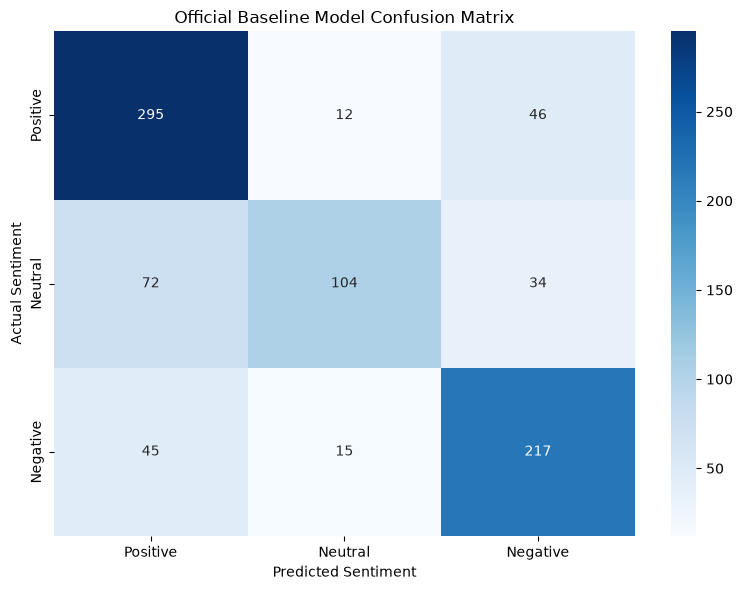

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Positive", "Neutral", "Negative"]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"]
)

plt.title("Official Baseline Model Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()
plt.show()

In [13]:
results = pd.DataFrame({
    "review": X_test.values,
    "actual_sentiment": y_test.values,
    "predicted_sentiment": y_pred
})

results["correct"] = (
    results["actual_sentiment"] ==
    results["predicted_sentiment"]
)

incorrect_predictions = results[
    results["correct"] == False
].copy()

print("Incorrect predictions:", len(incorrect_predictions))
print("Correct predictions:", len(results) - len(incorrect_predictions))

incorrect_predictions.head(20)

Incorrect predictions: 224
Correct predictions: 616


,review,actual_sentiment,predicted_sentiment,correct
0,the phone stays responsive under a busy worklo...,Neutral,Positive,False
1,usually leaves plenty of charge by bedtime. at...,Neutral,Negative,False
2,colors are pleasing without looking excessive....,Neutral,Positive,False
14,is adequate for most daily tasks. daylight sho...,Positive,Negative,False
15,the panel looks bright in most situations. pho...,Neutral,Positive,False
24,brightness is okay for my usual use. the finis...,Positive,Negative,False
25,photos have a pleasing amount of detail. my ro...,Neutral,Negative,False
32,charging speed is fairly ordinary. it is comfo...,Positive,Negative,False
35,i bought it after comparing a few phones in th...,Positive,Negative,False
43,the camera handles portraits with good separat...,Neutral,Positive,False


In [14]:
import os
import joblib

os.makedirs("../models/trained_models", exist_ok=True)

joblib.dump(
    baseline_model,
    "../models/trained_models/tfidf_logistic_baseline.pkl"
)

print("Baseline model saved successfully.")

Baseline model saved successfully.


In [15]:
baseline_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    "Score": [
        accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_f1
    ]
})

baseline_summary

,Metric,Score
0,Accuracy,0.733333
1,Macro Precision,0.746851
2,Macro Recall,0.704775
3,Macro F1,0.712437
4,Weighted F1,0.725930
